# Flight Delay and Cancellation Analysis (Part 1)

This notebook contains one consolidated and functional Part 1 workflow.
It merges the previous organized narrative with the currently working implementation.

## Notebook Goals

- Build a reliable preprocessing and feature-engineering pipeline.
- Perform exploratory analysis and dimensionality reduction.
- Run hypothesis testing to statistically validate feature relevance.
- Save intermediate and final checkpoints for reproducibility.

## Execution Phases

1. Problem formulation
2. Data loading and cleansing
3. Feature engineering and transformation
4. EDA and dimensionality reduction
5. Hypothesis testing and artifact export

> Tip: set `NROWS = 10000` for a quick run, or `NROWS = None` for the full dataset.


In [1]:
from pathlib import Path
import sys
import logging

import pandas as pd

# Resolve project root dynamically to avoid hardcoded absolute paths.
project_root = Path.cwd().resolve()
while project_root != project_root.parent and project_root.name != "DataScience_IA":
    project_root = project_root.parent

if project_root.name != "DataScience_IA":
    raise FileNotFoundError("Could not locate project root folder 'DataScience_IA'.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Project_Code.PythonCode.DataPreProcessor.FlightDataCleaner import FlightDataCleaner
from Project_Code.PythonCode.FeatureEngeneering.FlightFeatureEngineer import FlightFeatureEngineer
from Project_Code.PythonCode.EDA.FlightEDA import FlightEDA
from Project_Code.PythonCode.Util.DataVisualization import DataVisualization
from Project_Code.PythonCode.Util.DataLoader import DataLoader
from Project_Code.PythonCode.HypothesisTesting.HypothesisTester import HypothesisTester


dataset_path = project_root / "DataSet" / "flights_sample_3m.csv"
output_dir = project_root / "Output_Files"
output_dir.mkdir(parents=True, exist_ok=True)

# DataLoader now auto-downloads the dataset if this local CSV is missing.
# Keep dataset_path as the target location where the CSV should exist/be created.

# Logger setup used across all notebook phases.
logger = logging.getLogger("part1_notebook")
logger.setLevel(logging.INFO)
if logger.handlers:
    logger.handlers.clear()

file_handler = logging.FileHandler(output_dir / "pipeline_part1_notebook.log", encoding="utf-8")
stream_handler = logging.StreamHandler()
formatter = logging.Formatter("%(asctime)s - %(levelname)s - %(message)s")
file_handler.setFormatter(formatter)
stream_handler.setFormatter(formatter)
logger.addHandler(file_handler)
logger.addHandler(stream_handler)

# Runtime configuration.
NROWS = 10000
TEST_SIZE = 0.2
RANDOM_STATE = 42

print("Project root:", project_root)
print("Dataset path:", dataset_path)
print("Output dir:", output_dir)


Project root: C:\Users\angel\Documents\Github\Data Science\DataScience_IA
Dataset path: C:\Users\angel\Documents\Github\Data Science\DataScience_IA\DataSet\flights_sample_3m.csv
Output dir: C:\Users\angel\Documents\Github\Data Science\DataScience_IA\Output_Files


## Phase 1 - Problem Formulation

This project studies domestic US flight operations (2019-2023) with two predictive targets and one exploratory objective.

### Main Analytical Objectives

1. **Regression task**: predict `ARR_DELAY` (arrival delay in minutes).
2. **Classification task**: predict `DELAY_CLASS` after feature engineering.
3. **Exploratory objective**: identify operational patterns and group-level behavior.

### Leakage-Aware Perspective

A key requirement is to avoid data leakage by excluding post-departure and post-arrival signals during modeling preparation.
This ensures that engineered features represent information realistically available before departure.


In [2]:
phase1_summary = pd.DataFrame(
    {
        "Objective": ["Regression", "Classification", "Pattern Discovery"],
        "Target / Focus": ["ARR_DELAY", "DELAY_CLASS", "EDA + Reduction"],
    }
)
phase1_summary


,Objective,Target / Focus
0,Regression,ARR_DELAY
1,Classification,DELAY_CLASS
2,Pattern Discovery,EDA + Reduction


## Phase 2 - Data Loading and Cleansing

This phase standardizes the raw data preparation pipeline and persists an intermediate checkpoint.

### Steps

1. Load data and create train/test split metadata.
2. Clean raw records (cancelled/diverted filtering, leakage column removal, outlier treatment, null handling).
3. Validate resulting cleaned dataset dimensions and quality.
4. Save checkpoint after feature generation (next phase).


In [3]:
logger.info("\n" + "=" * 80)
logger.info("PHASE 2: DATA LOADING AND CLEANSING")
logger.info("=" * 80)

# STEP 1: Data load and train/test split
logger.info("[STEP 1] Loading dataset and splitting train/test...")
loader = DataLoader(str(dataset_path), test_size=TEST_SIZE, random_state=RANDOM_STATE)
data_train, data_test, target_train, target_test = loader.load_data(nrows=NROWS)

print("Train shape:", data_train.shape)
print("Test shape:", data_test.shape)
print("Target train shape:", target_train.shape if target_train is not None else None)
print("Target test shape:", target_test.shape if target_test is not None else None)

data_train.head(3)


2026-03-20 17:29:09,616 - INFO - 
2026-03-20 17:29:09,617 - INFO - PHASE 2: DATA LOADING AND CLEANSING
2026-03-20 17:29:09,618 - INFO - ================================================================================
2026-03-20 17:29:09,619 - INFO - [STEP 1] Loading dataset and splitting train/test...


A carregar o dataset a partir de: C:\Users\angel\Documents\Github\Data Science\DataScience_IA\DataSet\flights_sample_3m.csv...
Dataset carregado com sucesso!
Dimensão original: 10000 linhas × 32 colunas
Split realizado: 8000 treino × 2000 teste
Train shape: (8000, 31)
Test shape: (2000, 31)
Target train shape: (8000,)
Target test shape: (2000,)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
9254,2022-12-06,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,2408,SAN,"San Diego, CA",BOI,"Boise, ID",...,0.0,130.0,120.0,106.0,749.0,NaN,NaN,NaN,NaN,NaN
1561,2023-05-26,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1242,BNA,"Nashville, TN",TPA,"Tampa, FL",...,0.0,105.0,111.0,88.0,612.0,NaN,NaN,NaN,NaN,NaN
1670,2020-06-23,Endeavor Air Inc.,Endeavor Air Inc.: 9E,9E,20363,4949,CID,"Cedar Rapids/Iowa City, IA",MSP,"Minneapolis, MN",...,0.0,69.0,58.0,40.0,220.0,NaN,NaN,NaN,NaN,NaN


In [4]:
# STEP 2: Raw cleaning
logger.info("[STEP 2] Cleaning raw data...")
cleaner = FlightDataCleaner(file_path=str(dataset_path))
df_clean = cleaner.load_and_clean(nrows=NROWS)

print("Clean shape:", df_clean.shape)
print("Numeric missing values after cleaning:", int(df_clean.select_dtypes(include=["number"]).isnull().sum().sum()))
df_clean.head(3)


2026-03-20 17:29:10,351 - INFO - [STEP 2] Cleaning raw data...


INICIANDO PROCESSO DE LIMPEZA DE DADOS

1. A carregar os dados...
   ✓ Dataset carregado: 10000 linhas × 32 colunas

2. A remover voos cancelados e desviados...
   ✓ Removidos 270 voos (cancelados/desviados)

3. A remover colunas com data leakage...
   ✓ Removidas 17 colunas com data leakage

4. A remover nulos na variável alvo...
   ✓ Removidas 0 linhas com ARR_DELAY nulo

5. A tratar outliers e missing values...
   ✓ DISTANCE: 536 outliers tratados
   ✓ CRS_ELAPSED_TIME: 480 outliers tratados
   ✓ Nenhum missing value encontrado

6. A remover colunas redundantes...
   ✓ Removidas 5 colunas redundantes

LIMPEZA CONCLUÍDA!
Dimensão final: 9730 linhas × 10 colunas
Redução: 270 linhas removidas (2.7%)

Clean shape: (9730, 10)
Numeric missing values after cleaning: 0


,FL_DATE,AIRLINE,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DELAY,CRS_ELAPSED_TIME,DISTANCE
0,2019-01-09,United Air Lines Inc.,UA,FLL,EWR,1155,1501,-14.0,186.0,1065.0
1,2022-11-19,Delta Air Lines Inc.,DL,MSP,SEA,2120,2315,-5.0,235.0,1399.0
2,2022-07-22,United Air Lines Inc.,UA,DEN,MSP,954,1252,0.0,118.0,680.0


## Phase 3 - Feature Engineering and Transformation

This phase converts cleaned operational fields into model-ready features.

### What is created in this step

- Temporal behavior features
- Route and interaction features
- Delay classification target (`DELAY_CLASS`)
- Encoded categorical columns
- Normalized numeric predictors


In [5]:
logger.info("\n" + "=" * 80)
logger.info("PHASE 3: FEATURE ENGINEERING")
logger.info("=" * 80)

# STEP 3: Generate features
logger.info("[STEP 3] Generating engineered features...")
engineer = FlightFeatureEngineer(df_clean)
df_features = engineer.generate_features()

# STEP 4: Encode categorical features
logger.info("[STEP 4] Encoding categorical variables...")
df_features = engineer.encode_categorical()

# STEP 5: Normalize numeric features
logger.info("[STEP 5] Normalizing numeric features...")
df_features = engineer.normalize_features()

print("Features shape:", df_features.shape)
print("Total columns:", len(df_features.columns))
print("DELAY_CLASS present:", "DELAY_CLASS" in df_features.columns)
df_features.head(3)


2026-03-20 17:29:10,537 - INFO - 
2026-03-20 17:29:10,539 - INFO - PHASE 3: FEATURE ENGINEERING
2026-03-20 17:29:10,539 - INFO - ================================================================================
2026-03-20 17:29:10,540 - INFO - [STEP 3] Generating engineered features...


INICIANDO FEATURE ENGINEERING

1. Processando features temporais...


2026-03-20 17:29:10,585 - INFO - [STEP 4] Encoding categorical variables...
2026-03-20 17:29:10,607 - INFO - [STEP 5] Normalizing numeric features...


   ✓ 10 features temporais criadas

2. Processando features de rota...
   ✓ 3 features de rota criadas

3. Processando features de categorização...
   ✓ 3 features de categorização criadas

4. Processando features de interação...
   ✓ 3 features de interação criadas

5. Criando variável de classificação (DELAY_CLASS)...
   ✓ Variável DELAY_CLASS criada (3 classes)

FEATURE ENGINEERING CONCLUÍDO!
Total de features novas: 20
Dimensão do dataset: 9730 linhas × 29 colunas

Codificando variáveis categóricas...
   ✓ DISTANCE_CAT codificada
   ✓ DURATION_CAT codificada
   ✓ SPEED_CAT codificada
   ✓ DELAY_CLASS codificada
   ✓ ROUTE codificada

Normalizando features numéricas (StandardScaler)...
   ✓ 23 features normalizadas
Features shape: (9730, 29)
Total columns: 29
DELAY_CLASS present: True


,AIRLINE,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DELAY,CRS_ELAPSED_TIME,DISTANCE,MONTH,...,ROUTE,ROUTE_FREQUENCY,PLANNED_SPEED_MPM,DISTANCE_CAT,DURATION_CAT,SPEED_CAT,DISTANCE_x_ELAPSED_TIME,DISTANCE_POW2,ELAPSED_TIME_POW2,DELAY_CLASS
0,United Air Lines Inc.,UA,FLL,EWR,-0.344378,0.031894,-14.0,1.032821,0.847114,-1.573485,...,-0.394492,1.960884,0.492582,-0.516844,-0.950455,-0.86486,0.772083,0.590724,0.880435,1
1,Delta Air Lines Inc.,DL,MSP,SEA,1.636647,1.611028,-5.0,1.962566,1.646799,1.384570,...,0.590863,-0.795219,0.654849,-0.516844,-0.950455,-0.86486,1.972896,1.661569,2.132297,1
2,United Air Lines Inc.,UA,DEN,MSP,-0.757005,-0.451158,0.0,-0.257439,-0.074680,0.201348,...,-0.794147,1.134053,0.518918,-0.516844,1.052128,-0.86486,-0.310878,-0.283445,-0.374036,1


In [6]:
# STEP 6: Intermediate checkpoint
logger.info("[STEP 6] Saving cleaned+features checkpoint...")
loader.data = df_features
checkpoint_clean_path = dataset_path.parent / "checkpoint_cleaned_features.pkl"
loader.save_checkpoint(str(checkpoint_clean_path))

print("Checkpoint created:", checkpoint_clean_path.exists())
print("Checkpoint path:", checkpoint_clean_path)


2026-03-20 17:29:11,271 - INFO - [STEP 6] Saving cleaned+features checkpoint...


Checkpoint salvo: C:\Users\angel\Documents\Github\Data Science\DataScience_IA\DataSet\checkpoint_cleaned_features.pkl
Checkpoint created: True
Checkpoint path: C:\Users\angel\Documents\Github\Data Science\DataScience_IA\DataSet\checkpoint_cleaned_features.pkl


## Phase 4 - Exploratory Data Analysis and Dimensionality Reduction

This section combines analytical diagnostics with visual diagnostics.

### Analytical diagnostics

- Distribution and descriptive summaries
- Variable ranges and correlation structure
- Data quality checks

### Dimensionality reduction

- PCA for linear structure
- UMAP (or t-SNE fallback) for non-linear structure


2026-03-20 17:29:11,293 - INFO - 
2026-03-20 17:29:11,294 - INFO - PHASE 4: EDA AND DIMENSIONALITY REDUCTION
2026-03-20 17:29:11,295 - INFO - ================================================================================
2026-03-20 17:29:11,296 - INFO - [STEP 7] Running full EDA...


INICIANDO ANALISE EXPLORATORIA (EDA)
INICIANDO EDA ANALITICA

ESTATISTICAS DESCRITIVAS
Resumo geral:
       CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME      DISTANCE  \
count  9.730000e+03  9.730000e+03      9.730000e+03  9.730000e+03   
mean  -1.036969e-16 -1.708808e-16      4.892740e-17 -4.381558e-17   
std    1.000051e+00  1.000051e+00      1.000051e+00  1.000051e+00   
min   -2.701078e+00 -2.878058e+00     -1.870263e+00 -1.556732e+00   
25%   -8.473319e-01 -7.402132e-01     -7.887217e-01 -7.857774e-01   
50%   -1.591748e-02  5.323368e-02     -1.246177e-01 -1.441134e-01   
75%    8.360257e-01  8.389207e-01      5.774351e-01  5.879342e-01   
max    2.127284e+00  1.696387e+00      3.138979e+00  3.148006e+00   

              MONTH   DAY_OF_WEEK   DAY_OF_YEAR       QUARTER    IS_WEEKEND  \
count  9.730000e+03  9.730000e+03  9.730000e+03  9.730000e+03  9.730000e+03   
mean   1.175718e-16  6.280234e-17  6.937468e-18 -1.181195e-16 -8.763117e-17   
std    1.000051e+00  1.000051e+00  1.000

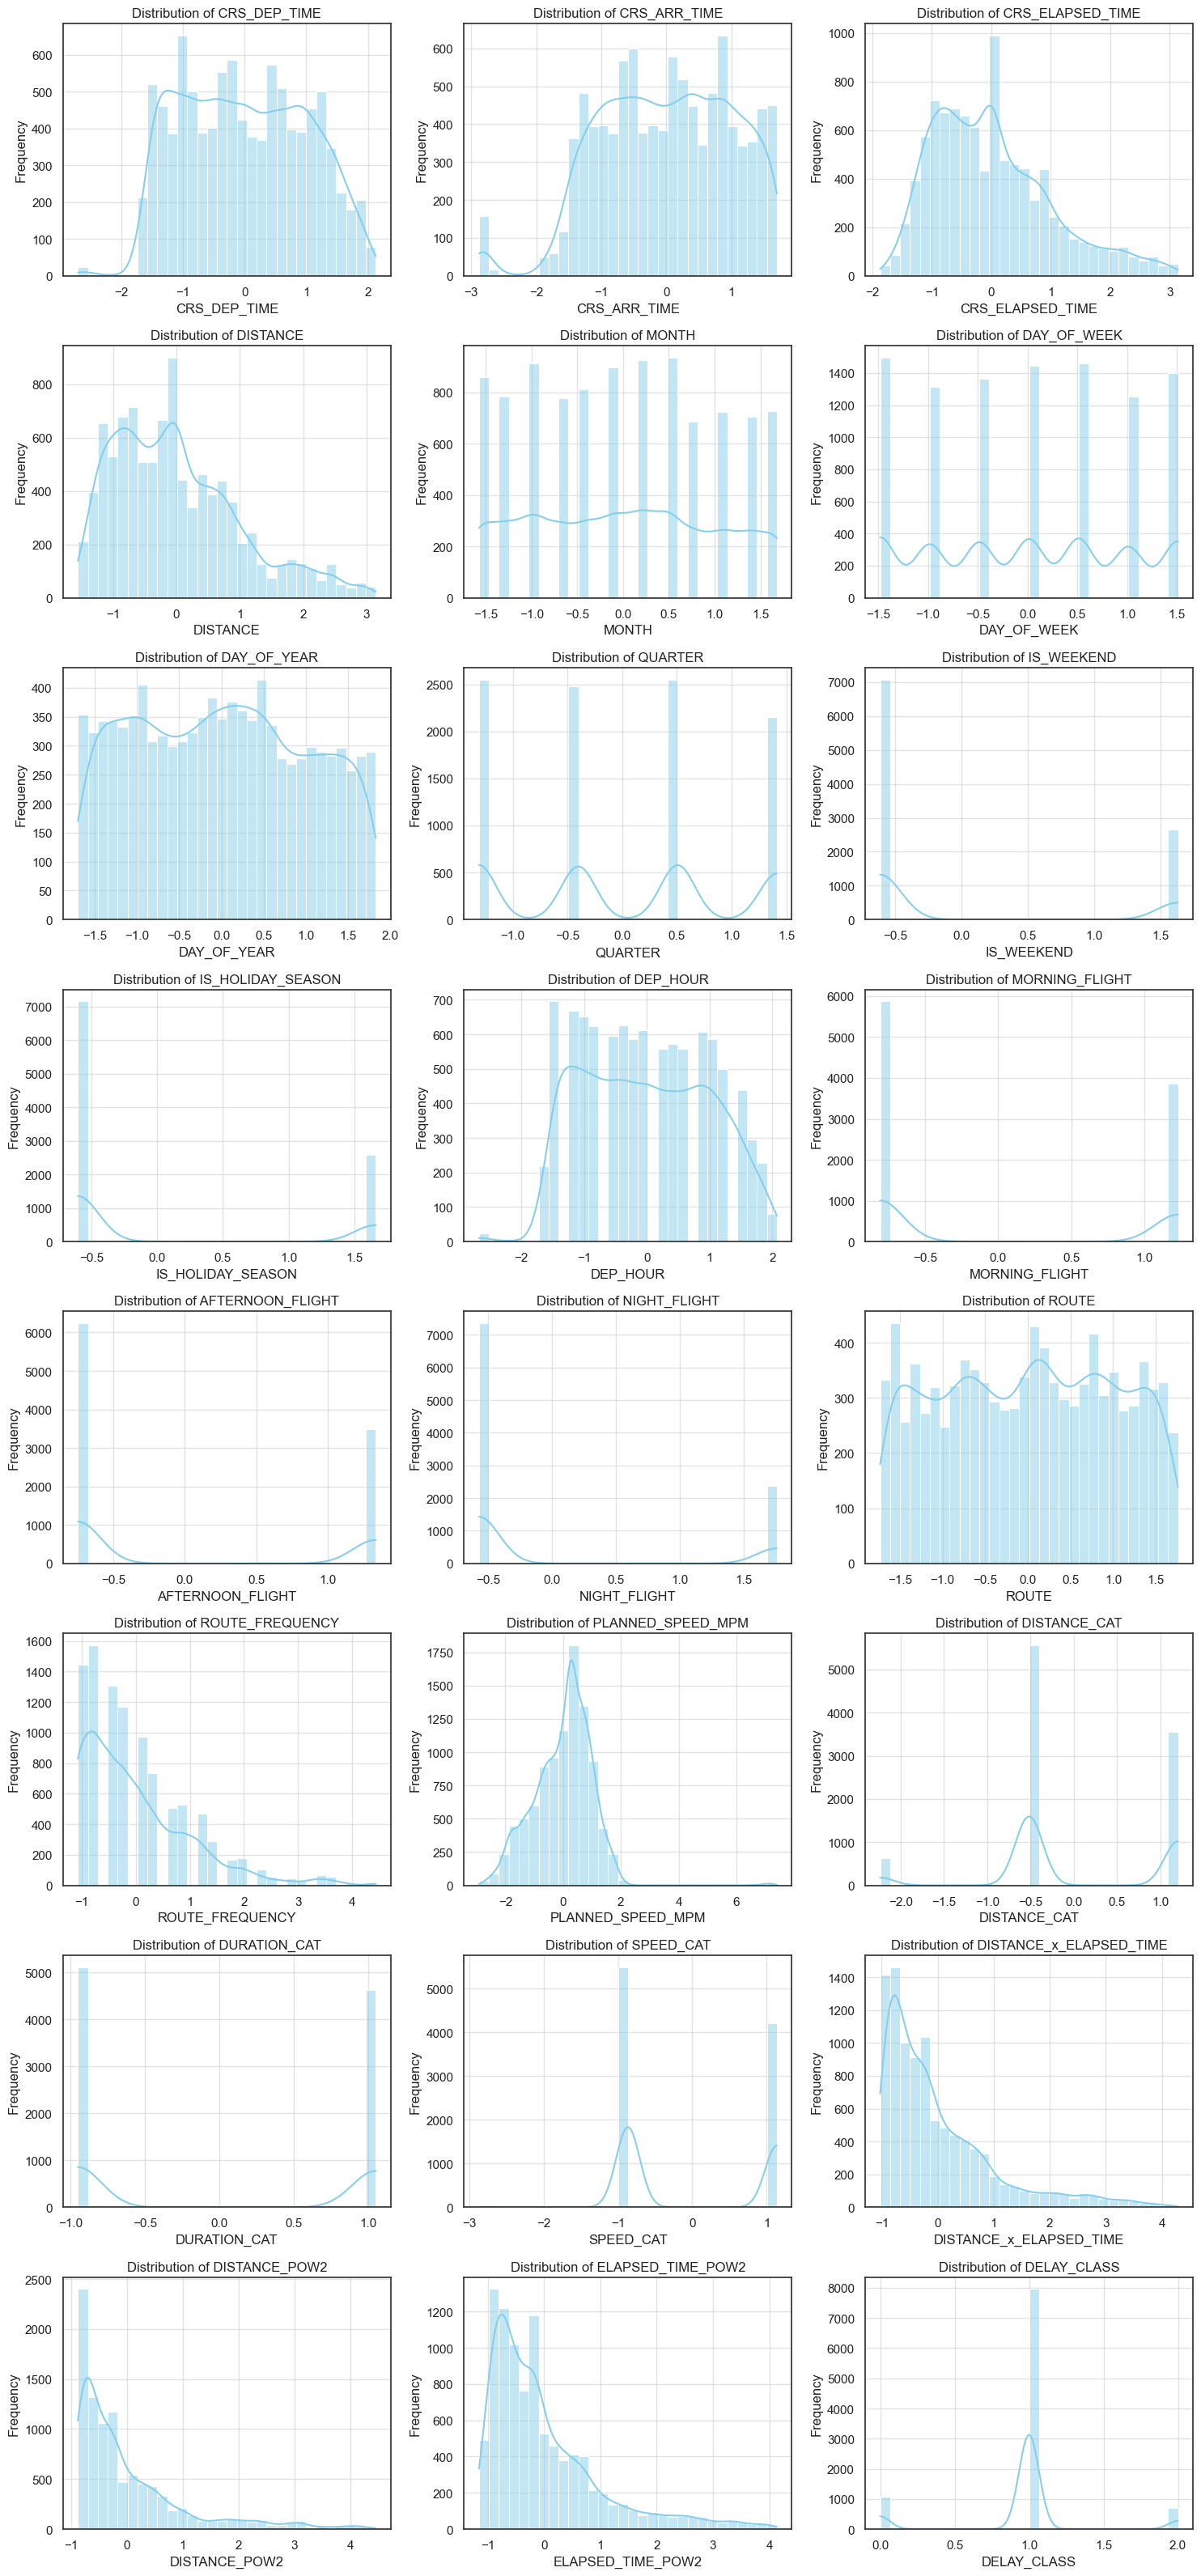

[OK] Histograms saved: eda_distributions.png
Generating correlation matrix...


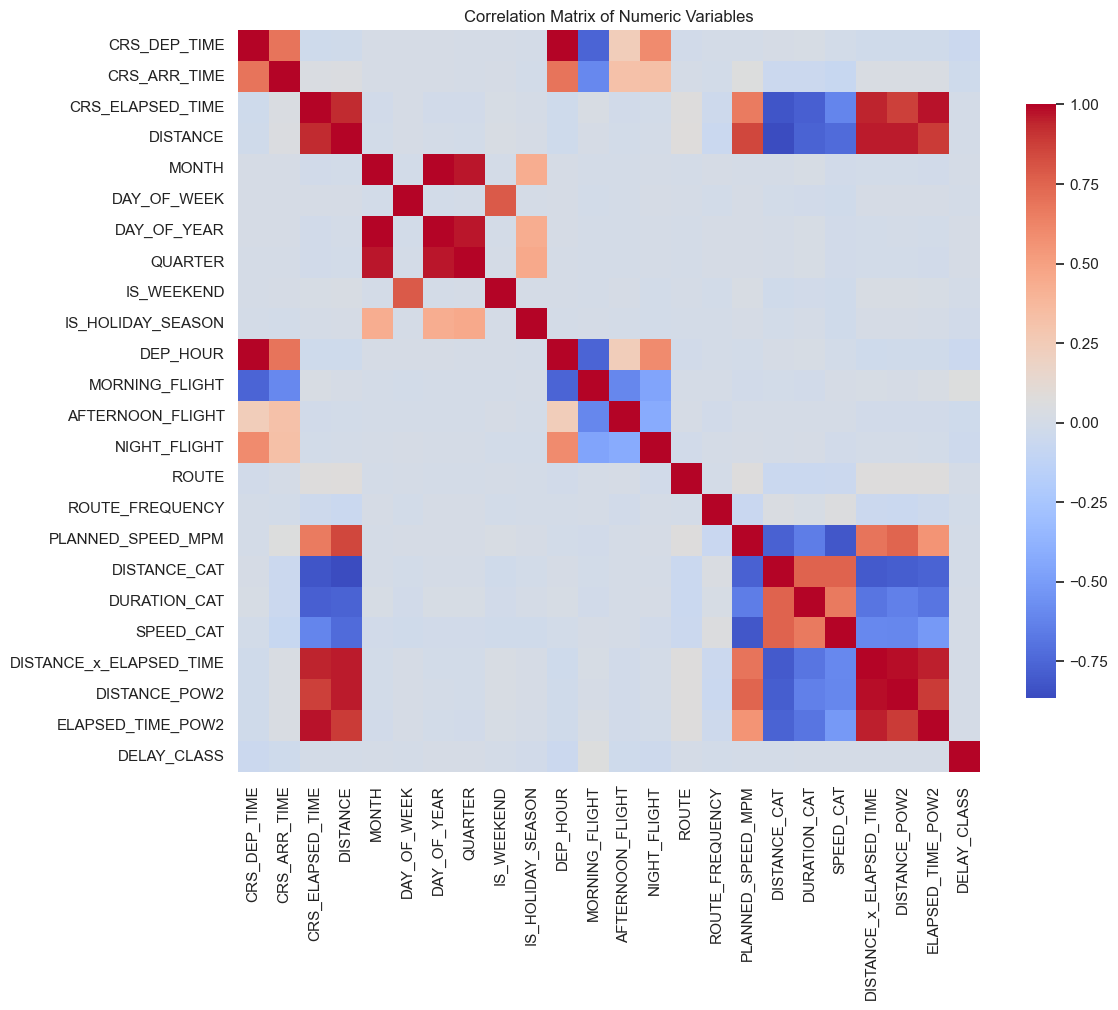

[OK] Correlation matrix saved: eda_correlation_matrix.png
Generating boxplots for 24 columns...


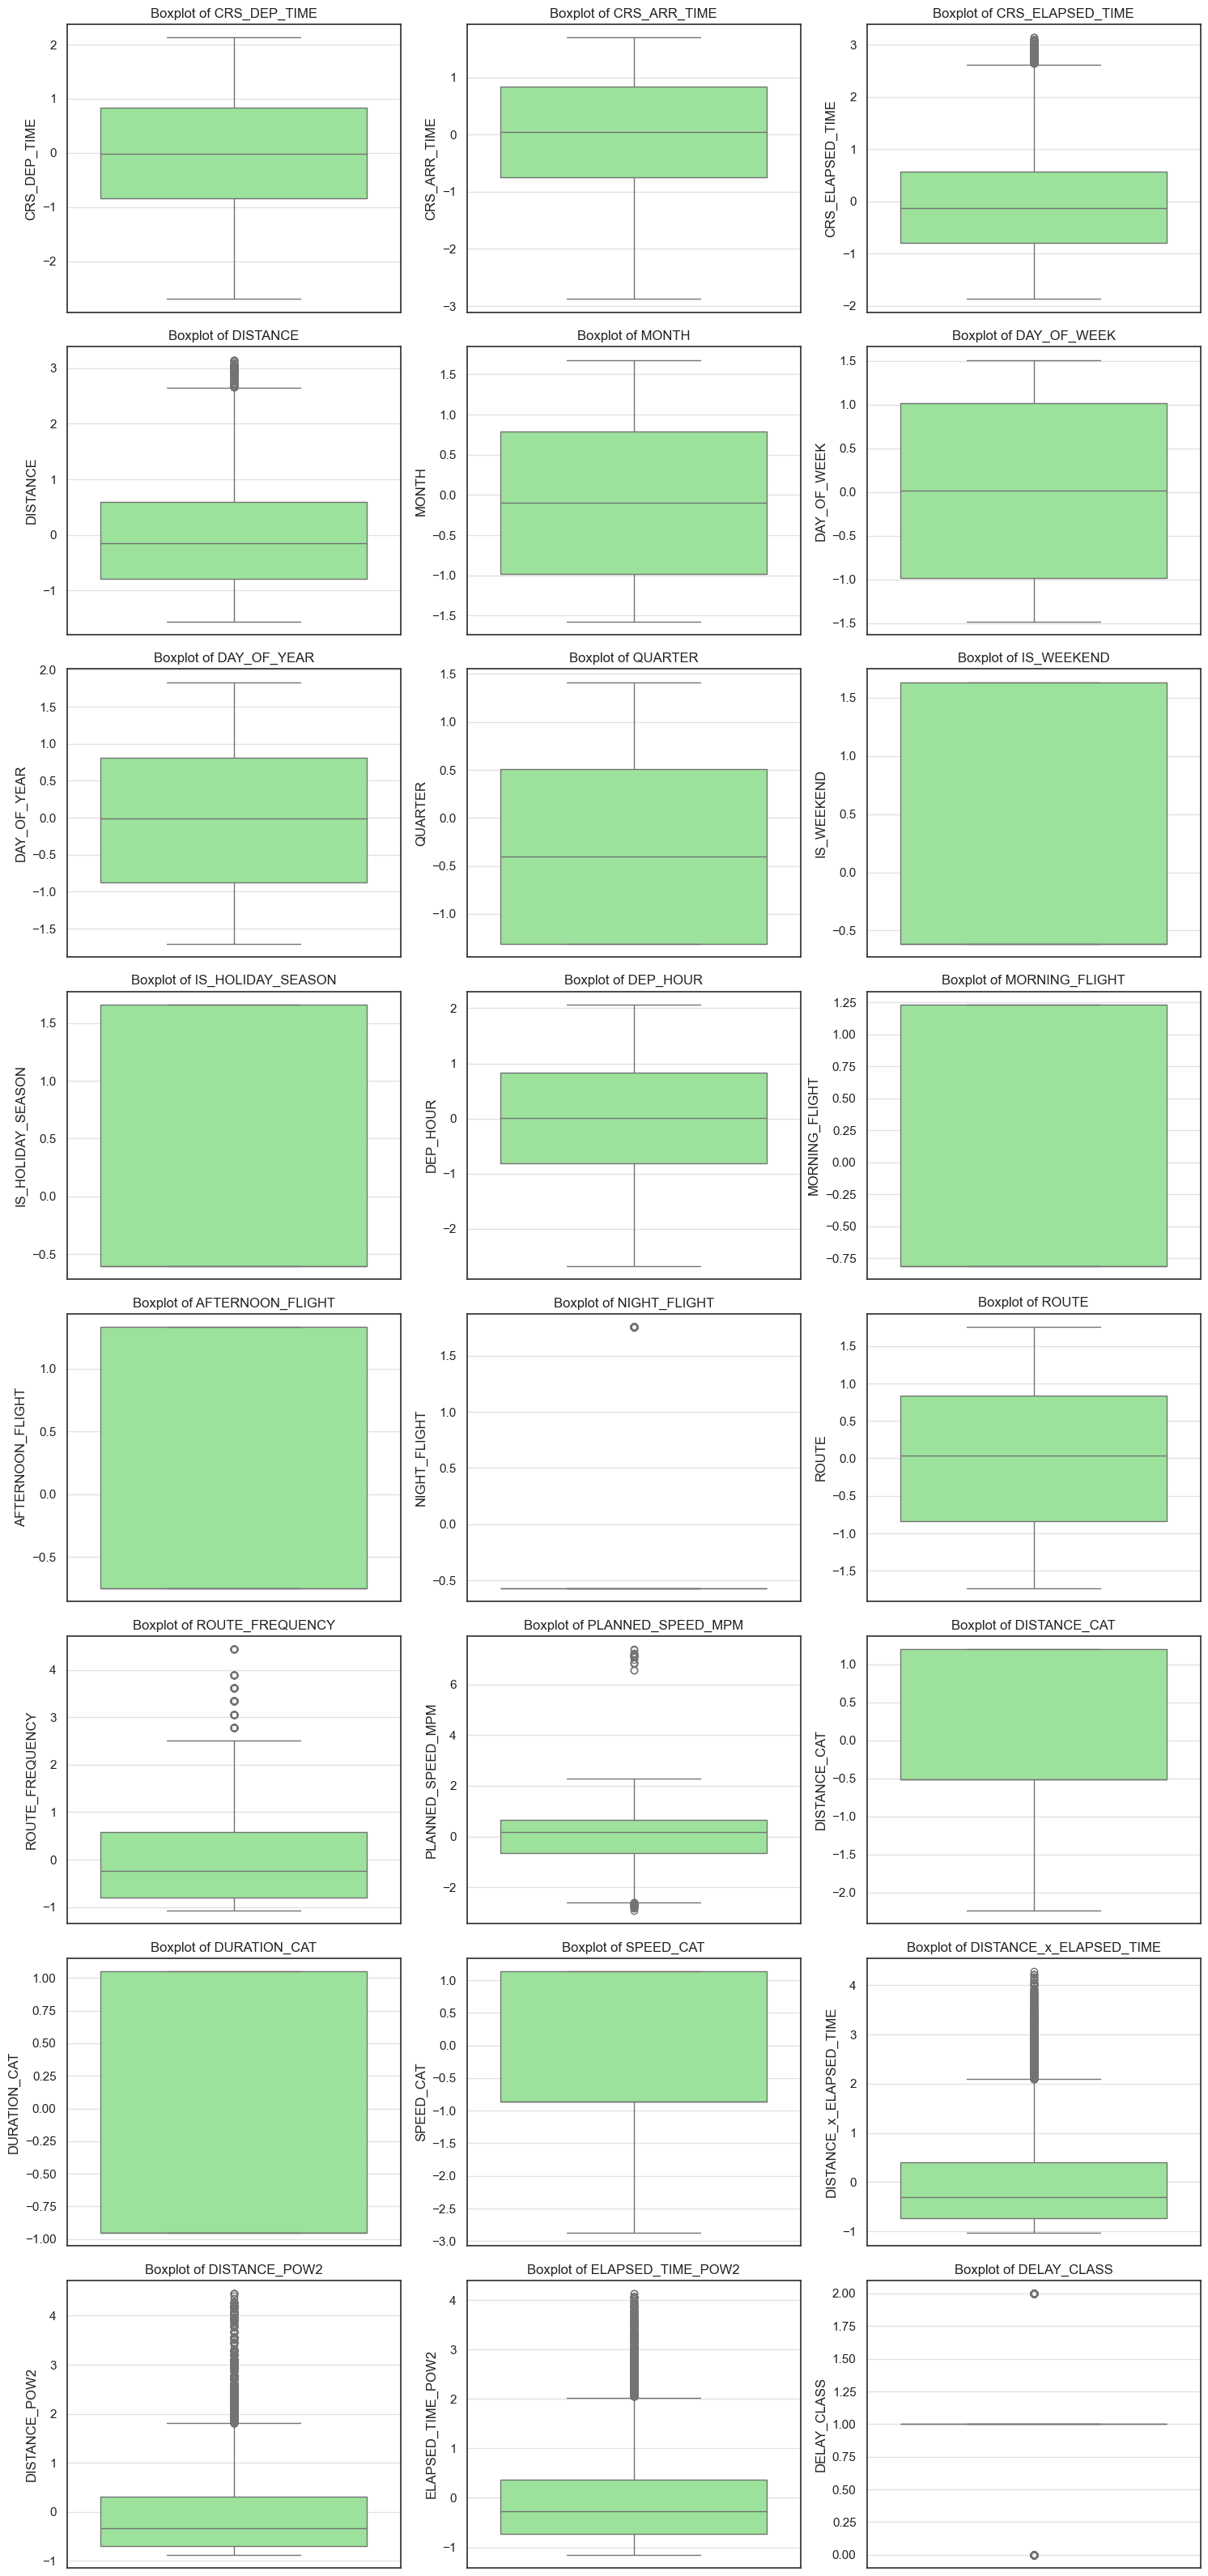

[OK] Boxplots saved: eda_boxplots.png

4. Generating target variable distribution...


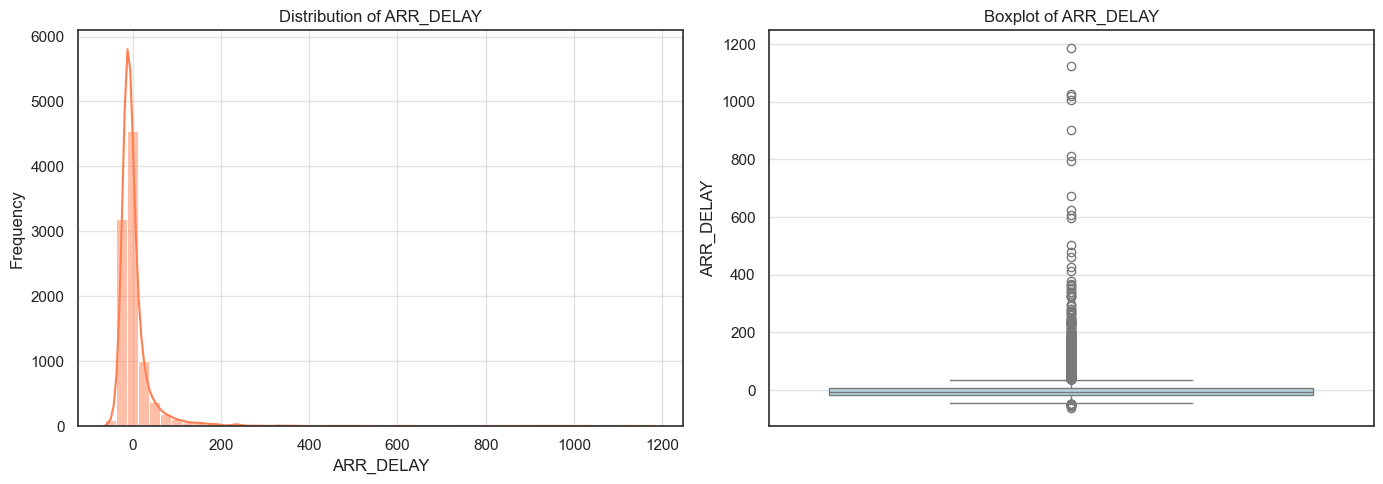

[OK] Target distribution saved: eda_target_distribution.png
EDA VISUAL (GRAFICOS BASE) CONCLUIDA!

INICIANDO EDA VISUAL AGRUPADA (DELAY_CLASS)
Generating grouped histograms for 6 columns...


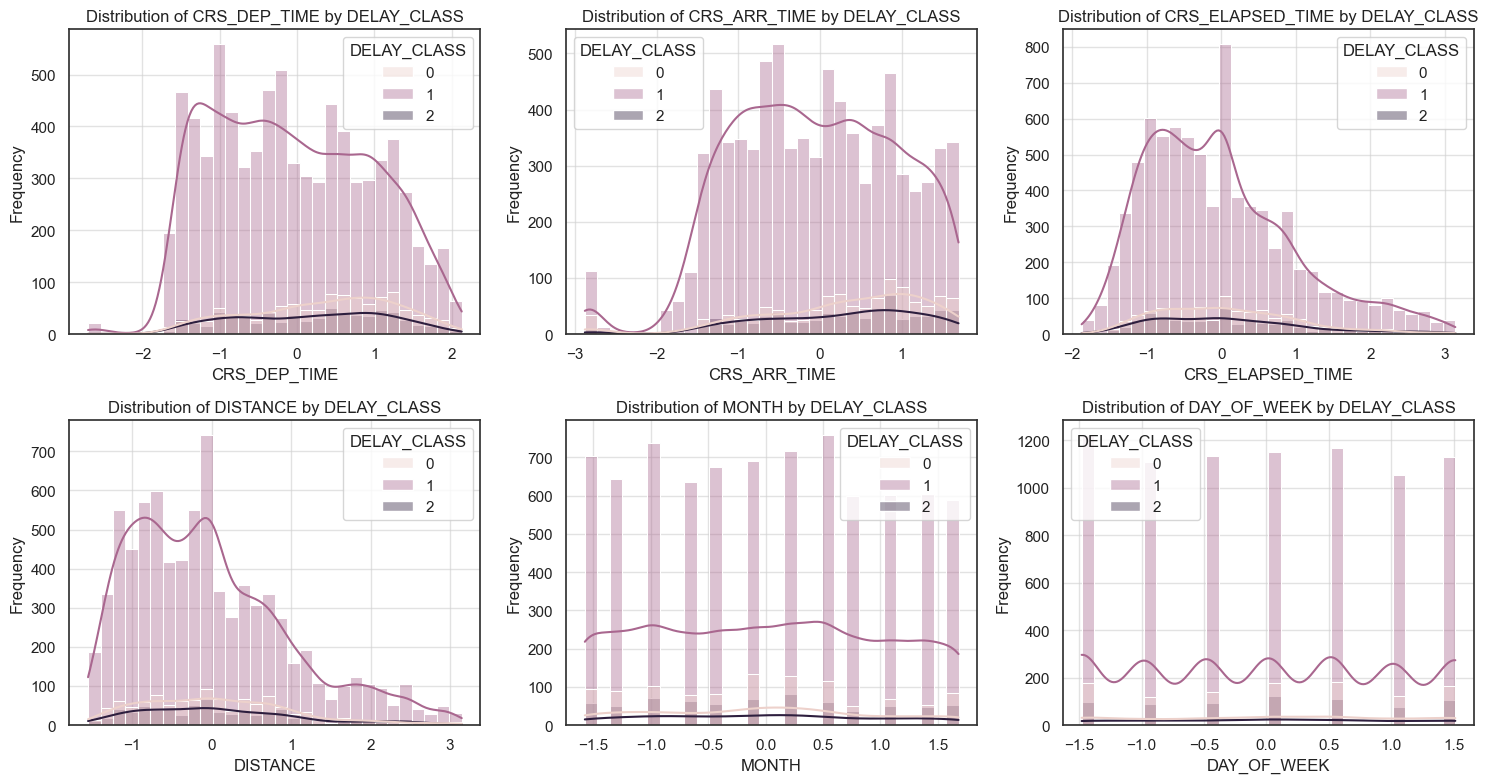

[OK] Grouped histograms saved: eda_grouped_distributions.png
Generating grouped boxplots for 6 columns...


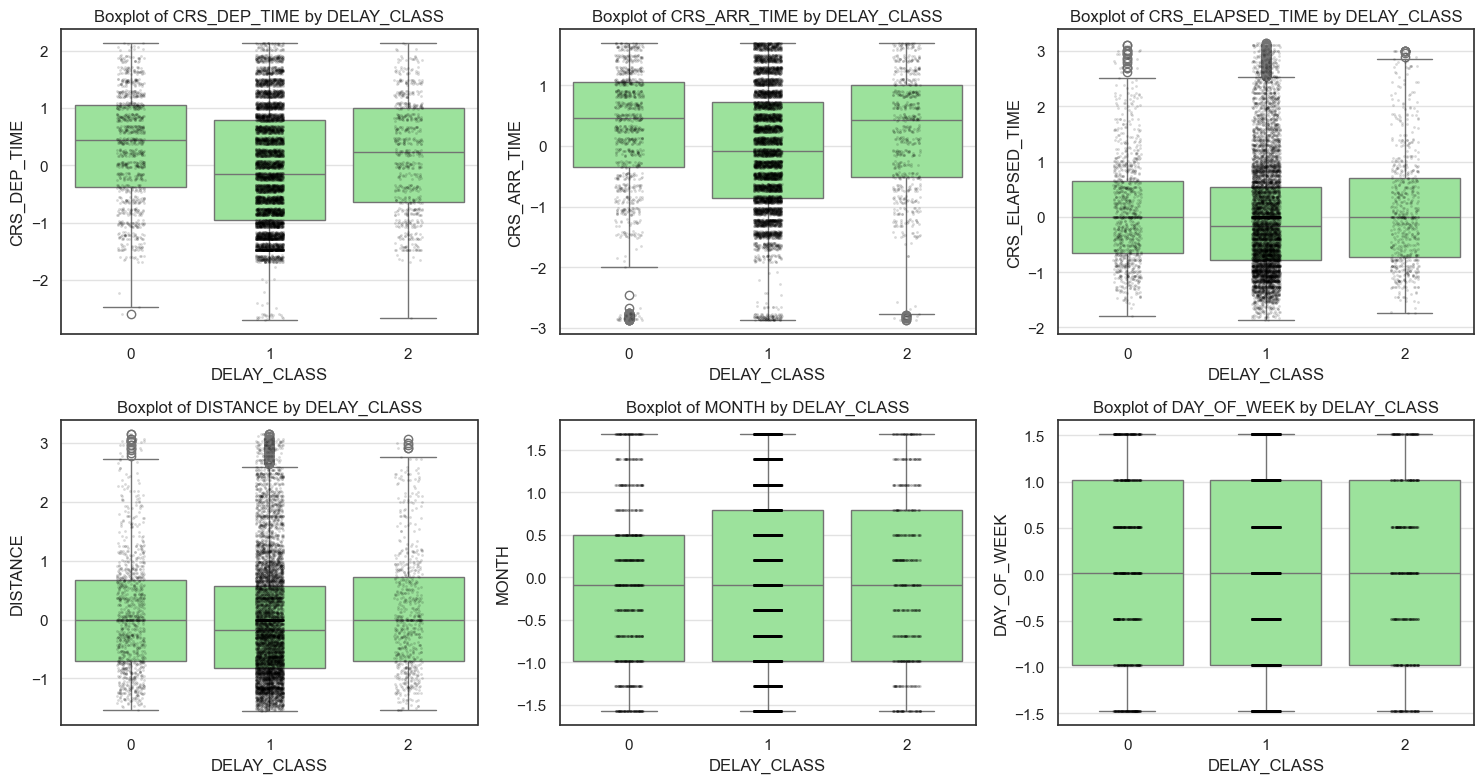

[OK] Grouped boxplots saved: eda_grouped_boxplots.png
EDA VISUAL AGRUPADA CONCLUIDA!

EDA CONCLUIDA!

Missing values total: 10
Duplicate rows: 0
Top outlier counts:
NIGHT_FLIGHT         2377
DELAY_CLASS          1771
ARR_DELAY             919
DISTANCE_POW2         755
ELAPSED_TIME_POW2     584
dtype: int64


In [7]:
logger.info("\n" + "=" * 80)
logger.info("PHASE 4: EDA AND DIMENSIONALITY REDUCTION")
logger.info("=" * 80)

# STEP 7: Run full EDA routine
logger.info("[STEP 7] Running full EDA...")
eda = FlightEDA(df_features, target_col="ARR_DELAY", output_dir=output_dir, group_col="DELAY_CLASS")
eda_report = eda.perform_eda()

print("Missing values total:", int(eda_report["quality"]["missing_values"].sum()))
print("Duplicate rows:", int(eda_report["quality"]["duplicate_count"]))
print("Top outlier counts:")
print(eda_report["quality"]["outlier_count"].head(5))


In [8]:
# STEP 8: PCA
logger.info("[STEP 8] Running PCA...")
pca_components = eda.run_pca(n_components=2, explained_variance_threshold=0.8)

print("PCA type:", type(pca_components))
print("PCA shape:", pca_components.shape)


2026-03-20 17:29:32,400 - INFO - [STEP 8] Running PCA...



EXECUTANDO PCA (Análise de Componentes Principais)

Componentes PCA necessários para 80.0% variância: 7
Variância explicada (primeiros 5 componentes):
  PC1: 30.36%
  PC2: 15.61%
  PC3: 13.42%
  PC4: 7.42%
  PC5: 6.23%

✓ PCA executado e visualizado: eda_pca_2d.png

PCA type: <class 'numpy.ndarray'>
PCA shape: (9720, 2)


### Detailed Analytical EDA Outputs

The following cells expose explicit analytical components from the EDA class.
These are useful when building a written report because each diagnostic can be cited independently.


In [9]:
eda.describe_variables()



ESTATISTICAS DESCRITIVAS
Resumo geral:
       CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME      DISTANCE  \
count  9.730000e+03  9.730000e+03      9.730000e+03  9.730000e+03   
mean  -1.036969e-16 -1.708808e-16      4.892740e-17 -4.381558e-17   
std    1.000051e+00  1.000051e+00      1.000051e+00  1.000051e+00   
min   -2.701078e+00 -2.878058e+00     -1.870263e+00 -1.556732e+00   
25%   -8.473319e-01 -7.402132e-01     -7.887217e-01 -7.857774e-01   
50%   -1.591748e-02  5.323368e-02     -1.246177e-01 -1.441134e-01   
75%    8.360257e-01  8.389207e-01      5.774351e-01  5.879342e-01   
max    2.127284e+00  1.696387e+00      3.138979e+00  3.148006e+00   

              MONTH   DAY_OF_WEEK   DAY_OF_YEAR       QUARTER    IS_WEEKEND  \
count  9.730000e+03  9.730000e+03  9.730000e+03  9.730000e+03  9.730000e+03   
mean   1.175718e-16  6.280234e-17  6.937468e-18 -1.181195e-16 -8.763117e-17   
std    1.000051e+00  1.000051e+00  1.000051e+00  1.000051e+00  1.000051e+00   
min   -1.573485e+00 -1

{'overall':        CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME      DISTANCE  \
 count  9.730000e+03  9.730000e+03      9.730000e+03  9.730000e+03   
 mean  -1.036969e-16 -1.708808e-16      4.892740e-17 -4.381558e-17   
 std    1.000051e+00  1.000051e+00      1.000051e+00  1.000051e+00   
 min   -2.701078e+00 -2.878058e+00     -1.870263e+00 -1.556732e+00   
 25%   -8.473319e-01 -7.402132e-01     -7.887217e-01 -7.857774e-01   
 50%   -1.591748e-02  5.323368e-02     -1.246177e-01 -1.441134e-01   
 75%    8.360257e-01  8.389207e-01      5.774351e-01  5.879342e-01   
 max    2.127284e+00  1.696387e+00      3.138979e+00  3.148006e+00   
 
               MONTH   DAY_OF_WEEK   DAY_OF_YEAR       QUARTER    IS_WEEKEND  \
 count  9.730000e+03  9.730000e+03  9.730000e+03  9.730000e+03  9.730000e+03   
 mean   1.175718e-16  6.280234e-17  6.937468e-18 -1.181195e-16 -8.763117e-17   
 std    1.000051e+00  1.000051e+00  1.000051e+00  1.000051e+00  1.000051e+00   
 min   -1.573485e+00 -1.479635e+00 -1

In [10]:
eda.determine_range()



AMPLITUDE DAS VARIAVEIS
Amplitude geral:
CRS_DEP_TIME                4.828362
CRS_ARR_TIME                4.574445
CRS_ELAPSED_TIME            5.009242
DISTANCE                    4.704738
MONTH                        3.25386
DAY_OF_WEEK                  2.99176
DAY_OF_YEAR                  3.53424
QUARTER                     2.723529
IS_WEEKEND                  2.245534
IS_HOLIDAY_SEASON           2.264026
DEP_HOUR                    4.742831
MORNING_FLIGHT              2.044181
AFTERNOON_FLIGHT            2.084483
NIGHT_FLIGHT                2.327373
ROUTE                       3.492547
ROUTE_FREQUENCY             5.512206
PLANNED_SPEED_MPM          10.302845
DISTANCE_CAT                3.438559
DURATION_CAT                2.002583
SPEED_CAT                   4.007839
DISTANCE_x_ELAPSED_TIME     5.317478
DISTANCE_POW2               5.336106
ELAPSED_TIME_POW2           5.286839
DELAY_CLASS                      2.0
ARR_DELAY                     1247.0
dtype: Float64

Amplitude por gru

{'overall': CRS_DEP_TIME                4.828362
 CRS_ARR_TIME                4.574445
 CRS_ELAPSED_TIME            5.009242
 DISTANCE                    4.704738
 MONTH                        3.25386
 DAY_OF_WEEK                  2.99176
 DAY_OF_YEAR                  3.53424
 QUARTER                     2.723529
 IS_WEEKEND                  2.245534
 IS_HOLIDAY_SEASON           2.264026
 DEP_HOUR                    4.742831
 MORNING_FLIGHT              2.044181
 AFTERNOON_FLIGHT            2.084483
 NIGHT_FLIGHT                2.327373
 ROUTE                       3.492547
 ROUTE_FREQUENCY             5.512206
 PLANNED_SPEED_MPM          10.302845
 DISTANCE_CAT                3.438559
 DURATION_CAT                2.002583
 SPEED_CAT                   4.007839
 DISTANCE_x_ELAPSED_TIME     5.317478
 DISTANCE_POW2               5.336106
 ELAPSED_TIME_POW2           5.286839
 DELAY_CLASS                      2.0
 ARR_DELAY                     1247.0
 dtype: Float64,
 'by_group':          

In [11]:
eda.assess_correlation()



CORRELACAO ENTRE VARIAVEIS
Correlacao geral:
                         CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME  \
CRS_DEP_TIME                 1.000000      0.691421         -0.031562   
CRS_ARR_TIME                 0.691421      1.000000          0.039571   
CRS_ELAPSED_TIME            -0.031562      0.039571          1.000000   
DISTANCE                    -0.026493      0.047172          0.931338   
MONTH                        0.010063      0.009479         -0.017163   
DAY_OF_WEEK                  0.014068      0.014220          0.013345   
DAY_OF_YEAR                  0.010584      0.010023         -0.015582   
QUARTER                      0.006633      0.006301         -0.019473   
IS_WEEKEND                   0.005112      0.012101          0.023030   
IS_HOLIDAY_SEASON           -0.001734     -0.006814          0.003932   
DEP_HOUR                     0.999327      0.690209         -0.032360   
MORNING_FLIGHT              -0.758557     -0.598829          0.025803   
AFTER

{'overall':                          CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME  \
 CRS_DEP_TIME                 1.000000      0.691421         -0.031562   
 CRS_ARR_TIME                 0.691421      1.000000          0.039571   
 CRS_ELAPSED_TIME            -0.031562      0.039571          1.000000   
 DISTANCE                    -0.026493      0.047172          0.931338   
 MONTH                        0.010063      0.009479         -0.017163   
 DAY_OF_WEEK                  0.014068      0.014220          0.013345   
 DAY_OF_YEAR                  0.010584      0.010023         -0.015582   
 QUARTER                      0.006633      0.006301         -0.019473   
 IS_WEEKEND                   0.005112      0.012101          0.023030   
 IS_HOLIDAY_SEASON           -0.001734     -0.006814          0.003932   
 DEP_HOUR                     0.999327      0.690209         -0.032360   
 MORNING_FLIGHT              -0.758557     -0.598829          0.025803   
 AFTERNOON_FLIGHT          

In [12]:
eda.assess_quality()



QUALIDADE DO DATASET
Missing values por coluna:
SPEED_CAT                  10
CRS_ARR_TIME                0
CRS_ELAPSED_TIME            0
DISTANCE                    0
MONTH                       0
DAY_OF_WEEK                 0
DAY_OF_YEAR                 0
QUARTER                     0
CRS_DEP_TIME                0
IS_WEEKEND                  0
IS_HOLIDAY_SEASON           0
MORNING_FLIGHT              0
DEP_HOUR                    0
NIGHT_FLIGHT                0
ROUTE                       0
ROUTE_FREQUENCY             0
AFTERNOON_FLIGHT            0
PLANNED_SPEED_MPM           0
DISTANCE_CAT                0
DURATION_CAT                0
DISTANCE_x_ELAPSED_TIME     0
DISTANCE_POW2               0
ELAPSED_TIME_POW2           0
DELAY_CLASS                 0
ARR_DELAY                   0
dtype: int64

Duplicados no dataframe: 0

Outliers por coluna (IQR):
NIGHT_FLIGHT               2377
DELAY_CLASS                1771
ARR_DELAY                   919
DISTANCE_POW2               755
ELAP

{'missing_values': SPEED_CAT                  10
 CRS_ARR_TIME                0
 CRS_ELAPSED_TIME            0
 DISTANCE                    0
 MONTH                       0
 DAY_OF_WEEK                 0
 DAY_OF_YEAR                 0
 QUARTER                     0
 CRS_DEP_TIME                0
 IS_WEEKEND                  0
 IS_HOLIDAY_SEASON           0
 MORNING_FLIGHT              0
 DEP_HOUR                    0
 NIGHT_FLIGHT                0
 ROUTE                       0
 ROUTE_FREQUENCY             0
 AFTERNOON_FLIGHT            0
 PLANNED_SPEED_MPM           0
 DISTANCE_CAT                0
 DURATION_CAT                0
 DISTANCE_x_ELAPSED_TIME     0
 DISTANCE_POW2               0
 ELAPSED_TIME_POW2           0
 DELAY_CLASS                 0
 ARR_DELAY                   0
 dtype: int64,
 'duplicate_count': 0,
 'outlier_count': NIGHT_FLIGHT               2377
 DELAY_CLASS                1771
 ARR_DELAY                   919
 DISTANCE_POW2               755
 ELAPSED_TIME_POW2  

### Visual EDA Outputs

These cells generate key plots used for interpretation and documentation.
All figures are written to `Output_Files`.


Generating histograms for 24 columns...


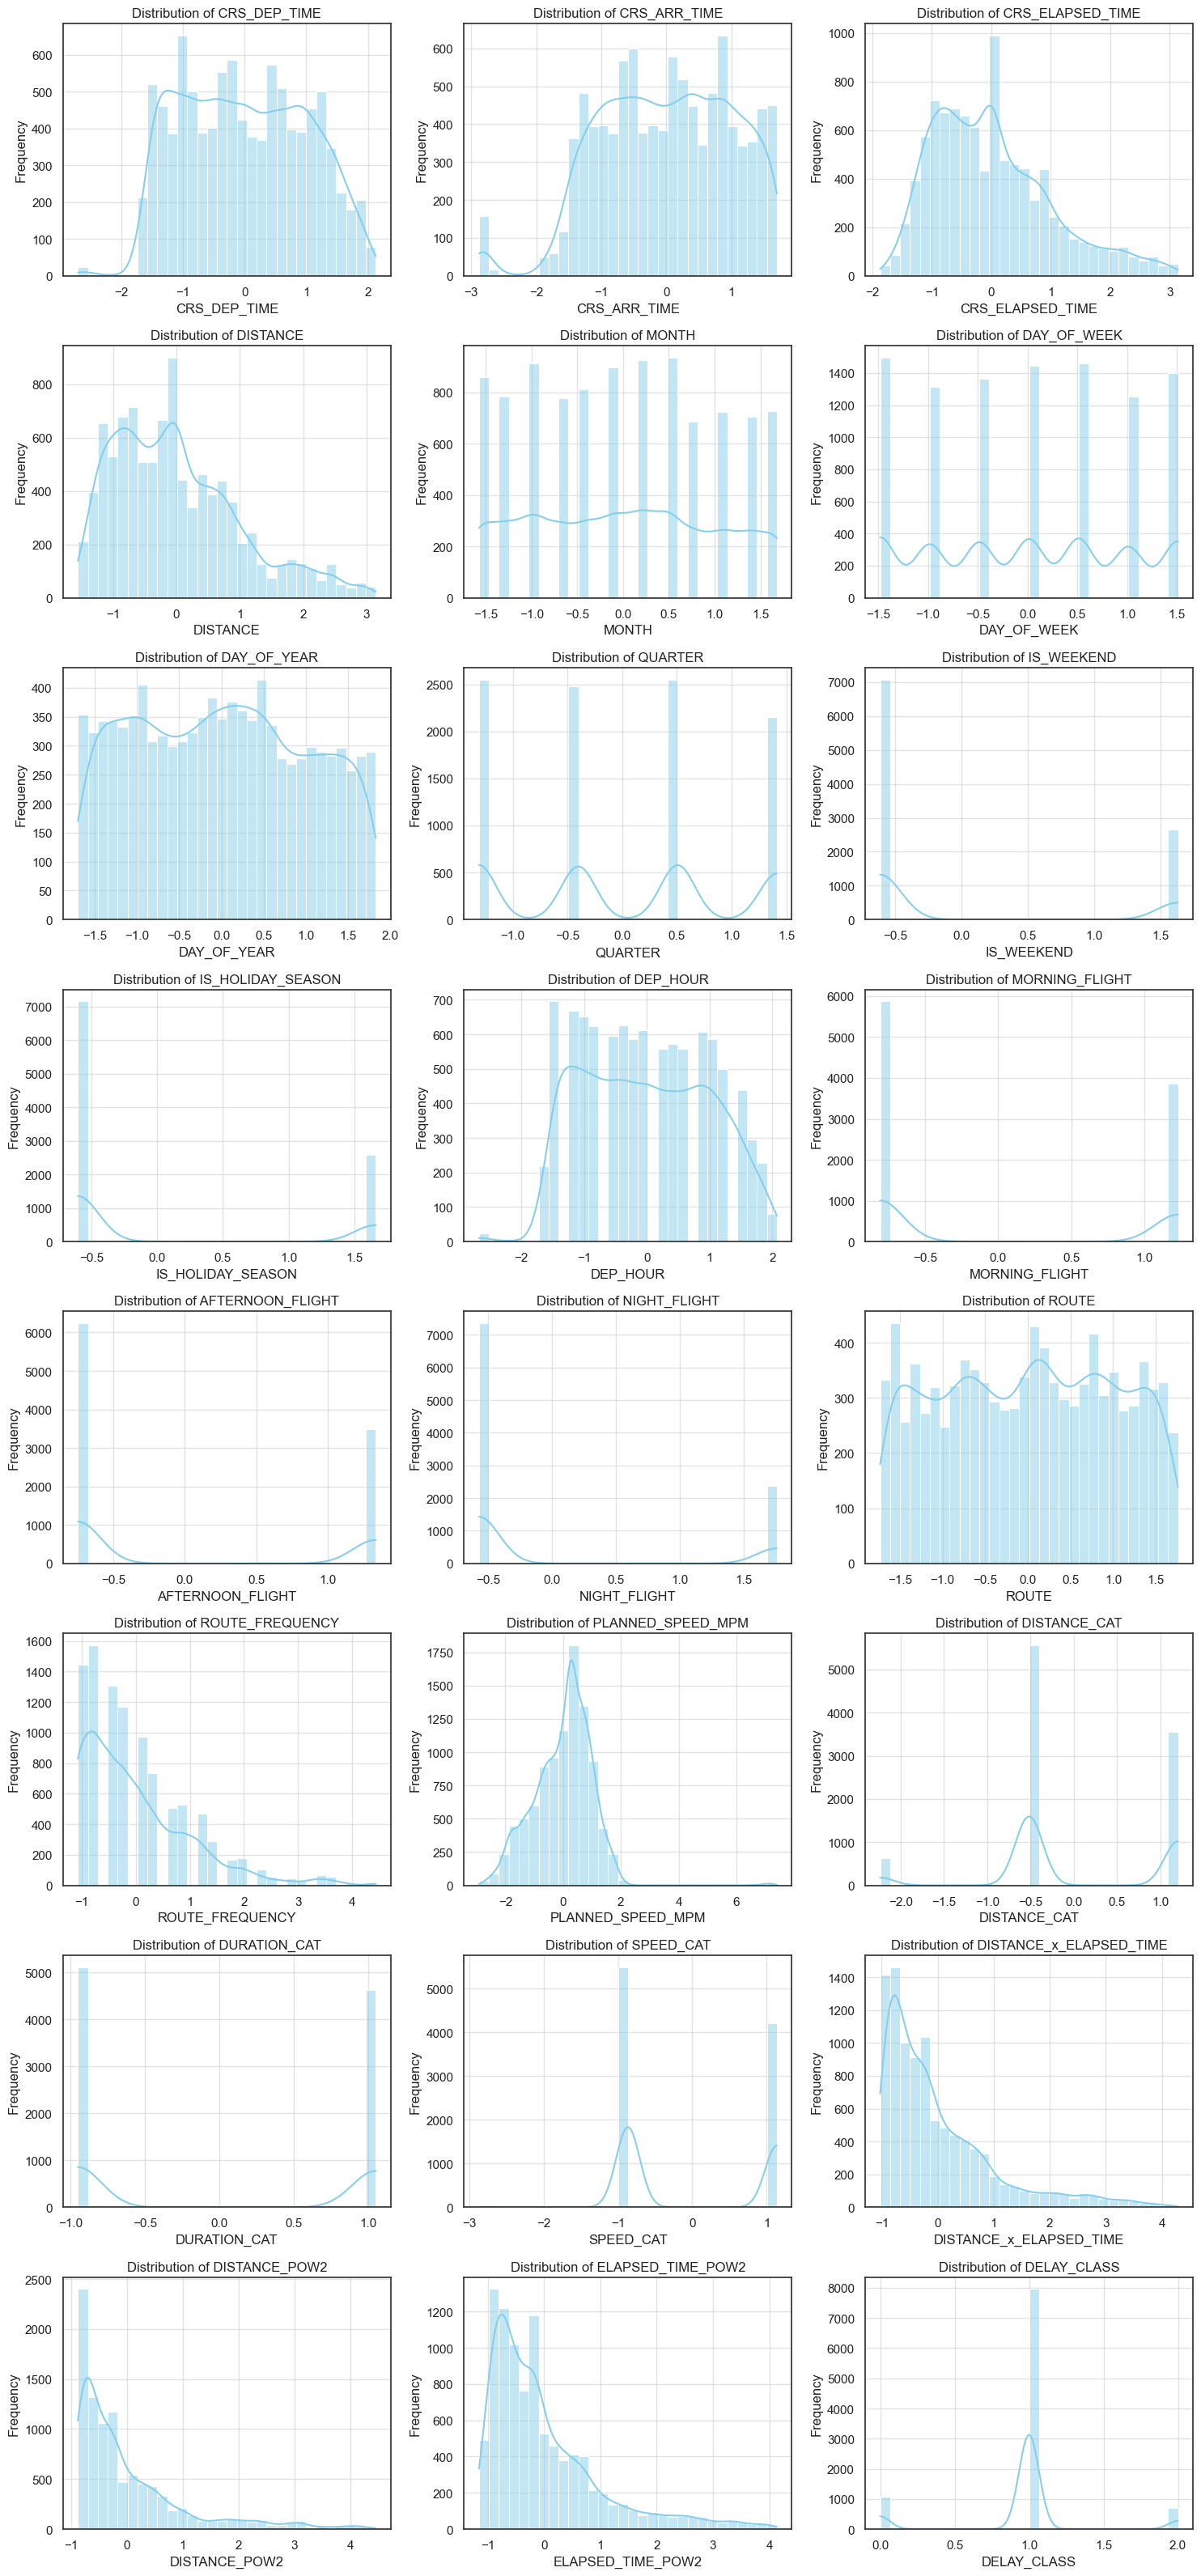

[OK] Histograms saved: eda_distributions.png


In [13]:
eda.viz.plot_distributions()


Generating correlation matrix...


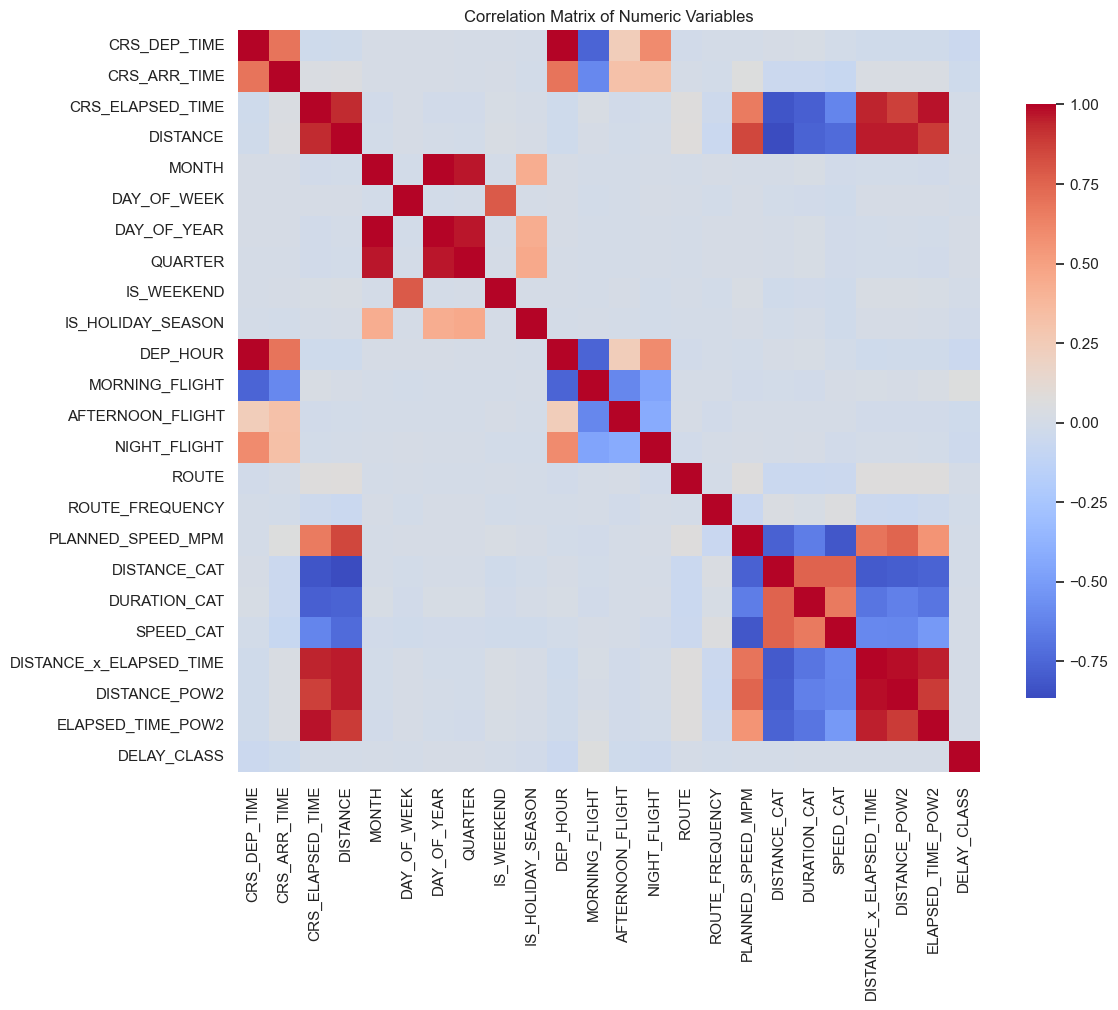

[OK] Correlation matrix saved: eda_correlation_matrix.png


In [14]:
eda.viz.plot_correlation_matrix(filename="eda_correlation_matrix.png")


Generating boxplots for 24 columns...


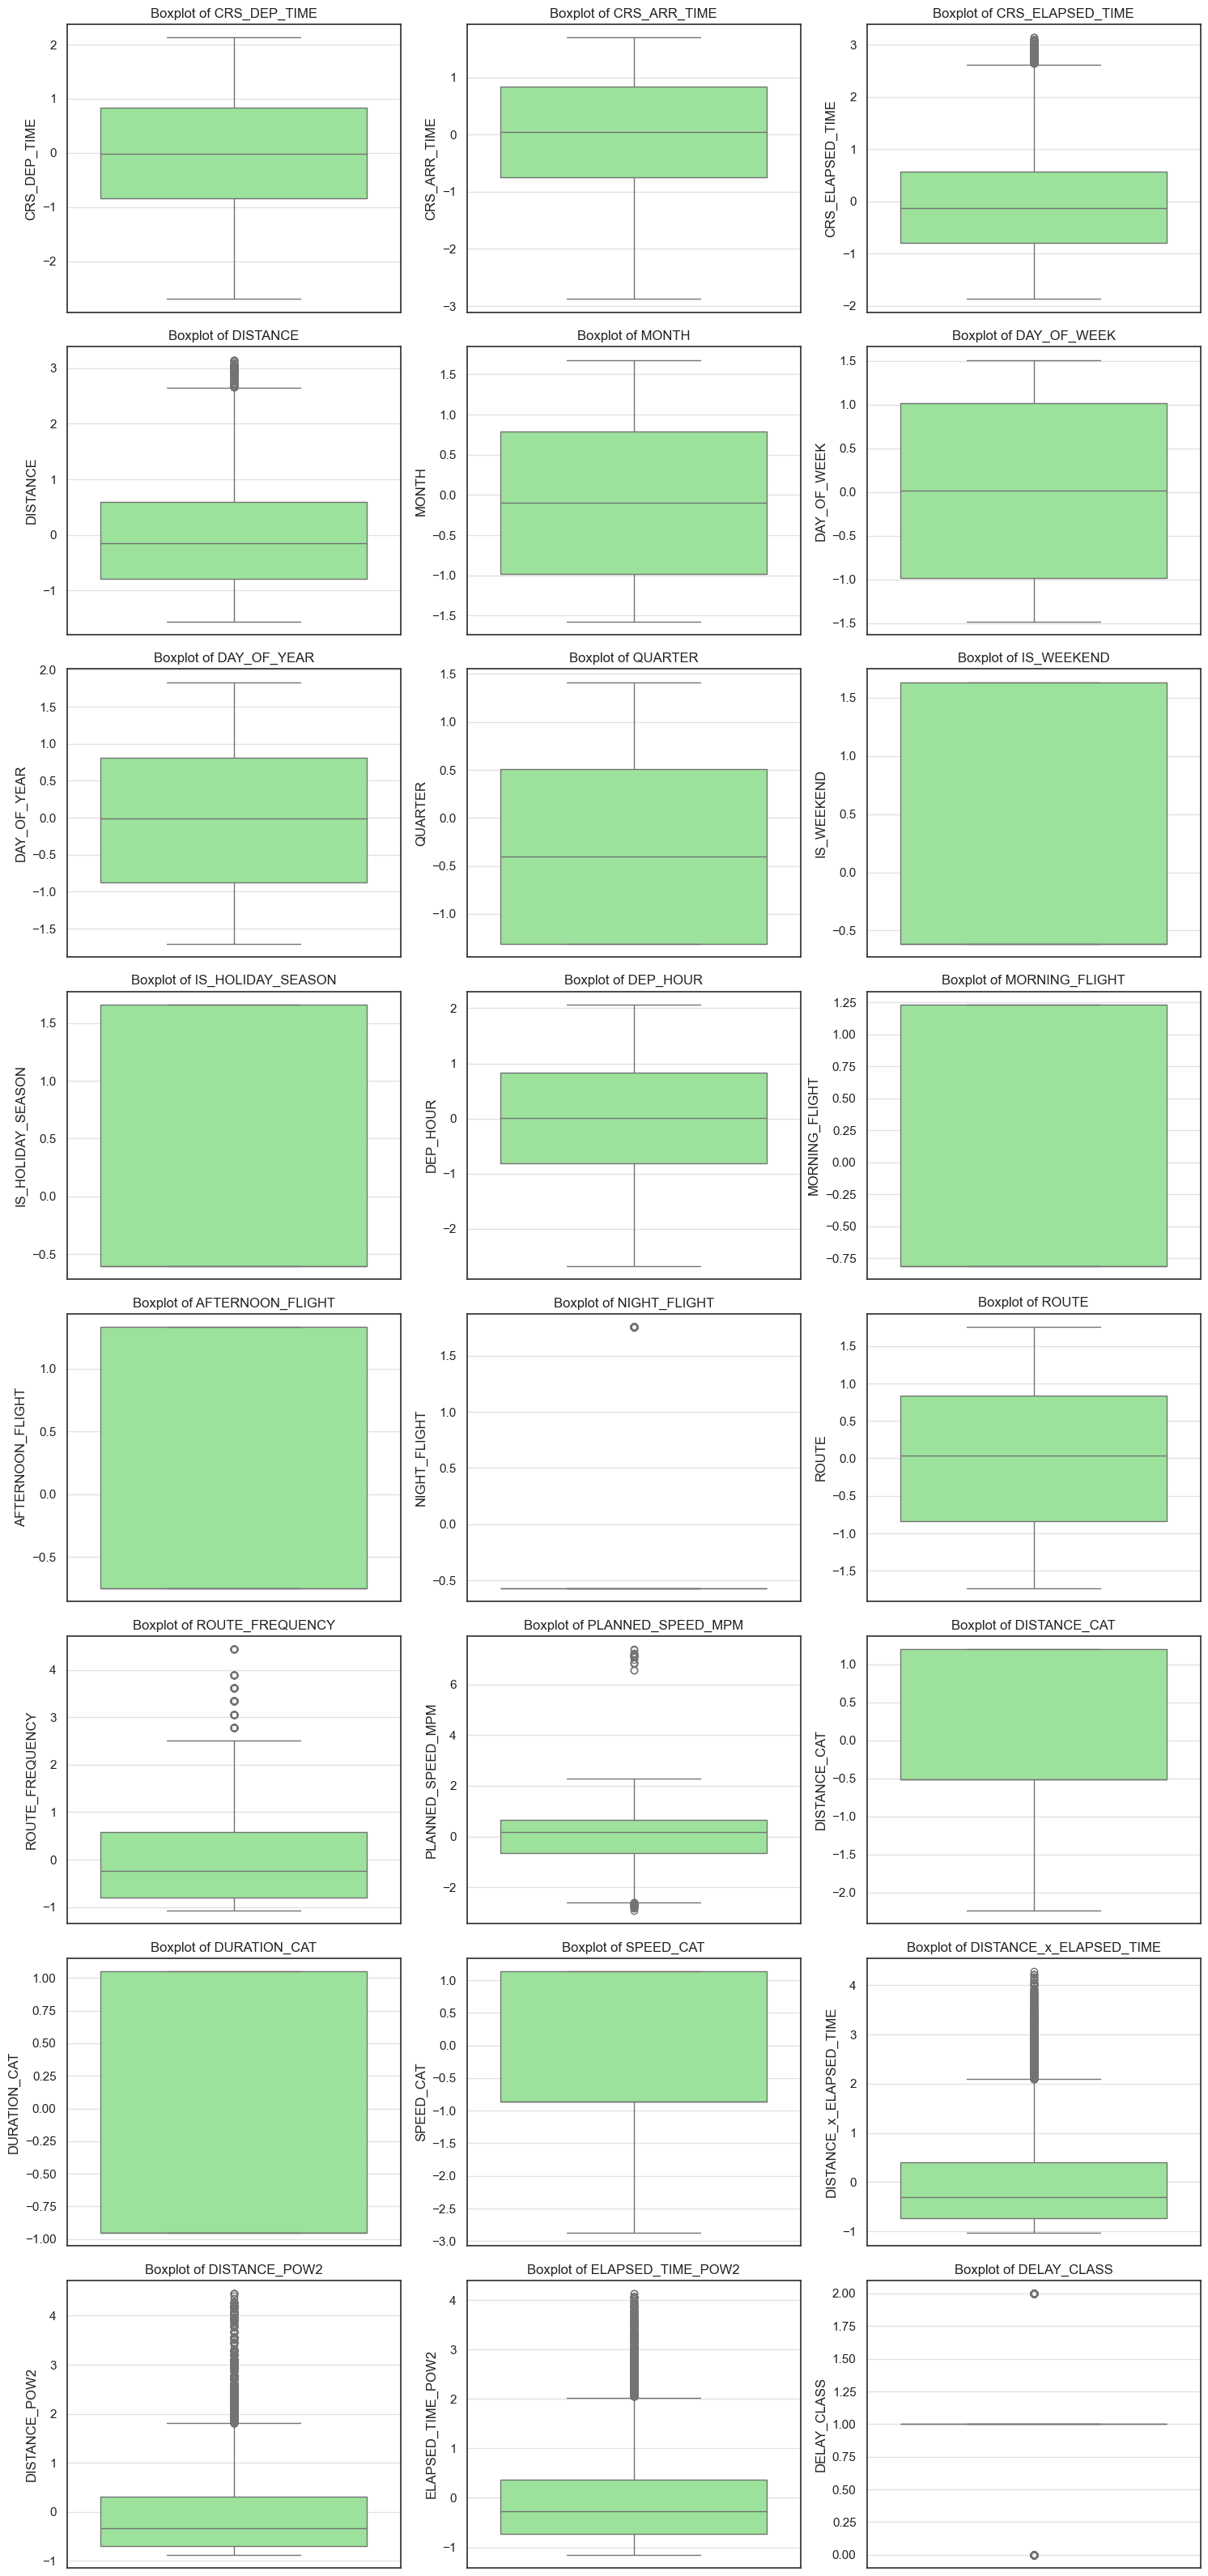

[OK] Boxplots saved: eda_boxplots.png


In [15]:
eda.viz.plot_boxplots(columns=eda.numeric_cols, filename="eda_boxplots.png")



4. Generating target variable distribution...


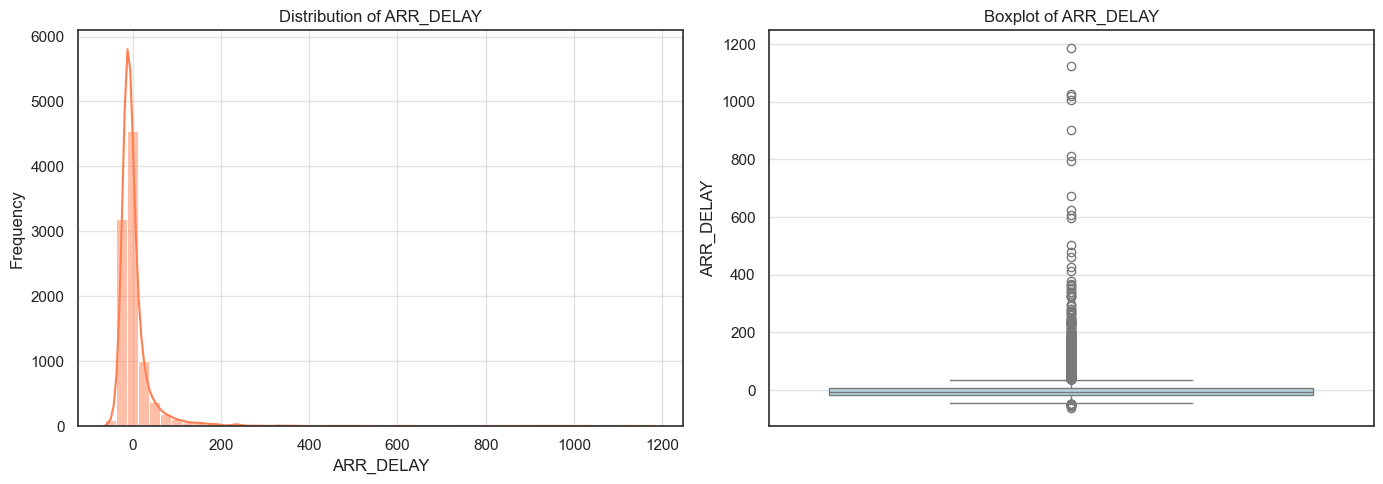

[OK] Target distribution saved: eda_target_distribution.png


In [16]:
eda.viz.plot_target_distribution(filename="eda_target_distribution.png")


2026-03-20 17:29:48,140 - INFO - [STEP 9] Running UMAP/t-SNE...



EXECUTANDO UMAP (Análise de Dimensionalidade Não-Linear)

Aplicando UMAP...


C:\Users\angel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


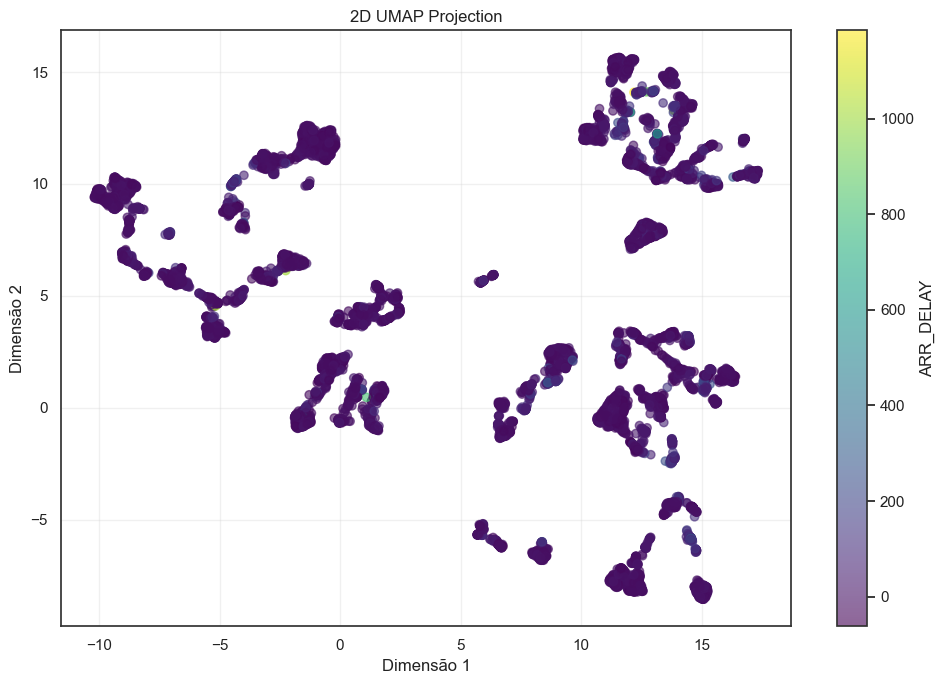


✓ UMAP executado e visualizado: eda_umap_2d.png

UMAP/t-SNE type: <class 'numpy.ndarray'>
UMAP/t-SNE shape: (9720, 2)


In [17]:
# STEP 9: UMAP/t-SNE
logger.info("[STEP 9] Running UMAP/t-SNE...")
umap_components = eda.run_umap_or_tsne(n_components=2, use_umap=True)

print("UMAP/t-SNE type:", type(umap_components))
print("UMAP/t-SNE shape:", umap_components.shape)


2026-03-20 17:30:23,360 - INFO - [STEP 10] Generating additional visual diagnostics...


Generating top 20 correlations heatmap...


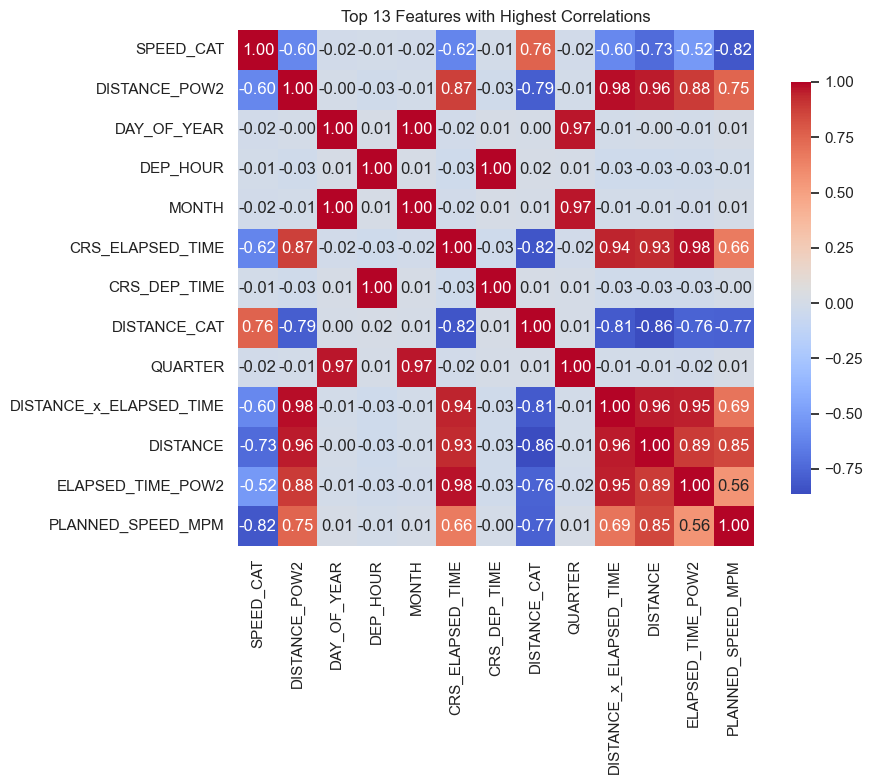

[OK] Heatmap saved: viz_heatmap_top_correlations.png
Generating grouped histograms for 4 columns...


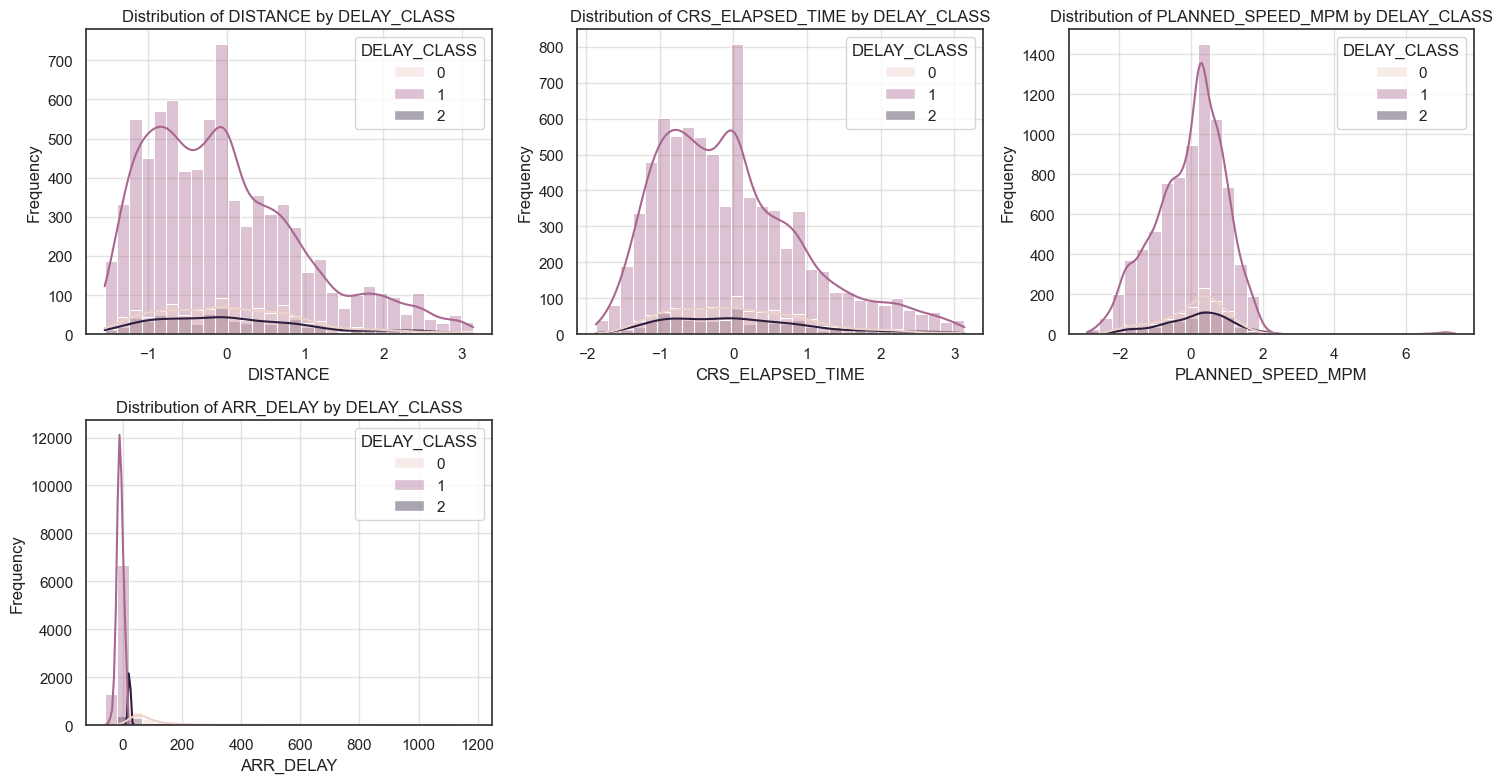

[OK] Grouped histograms saved: viz_grouped_distributions_delay_class.png
Generating grouped boxplots for 4 columns...


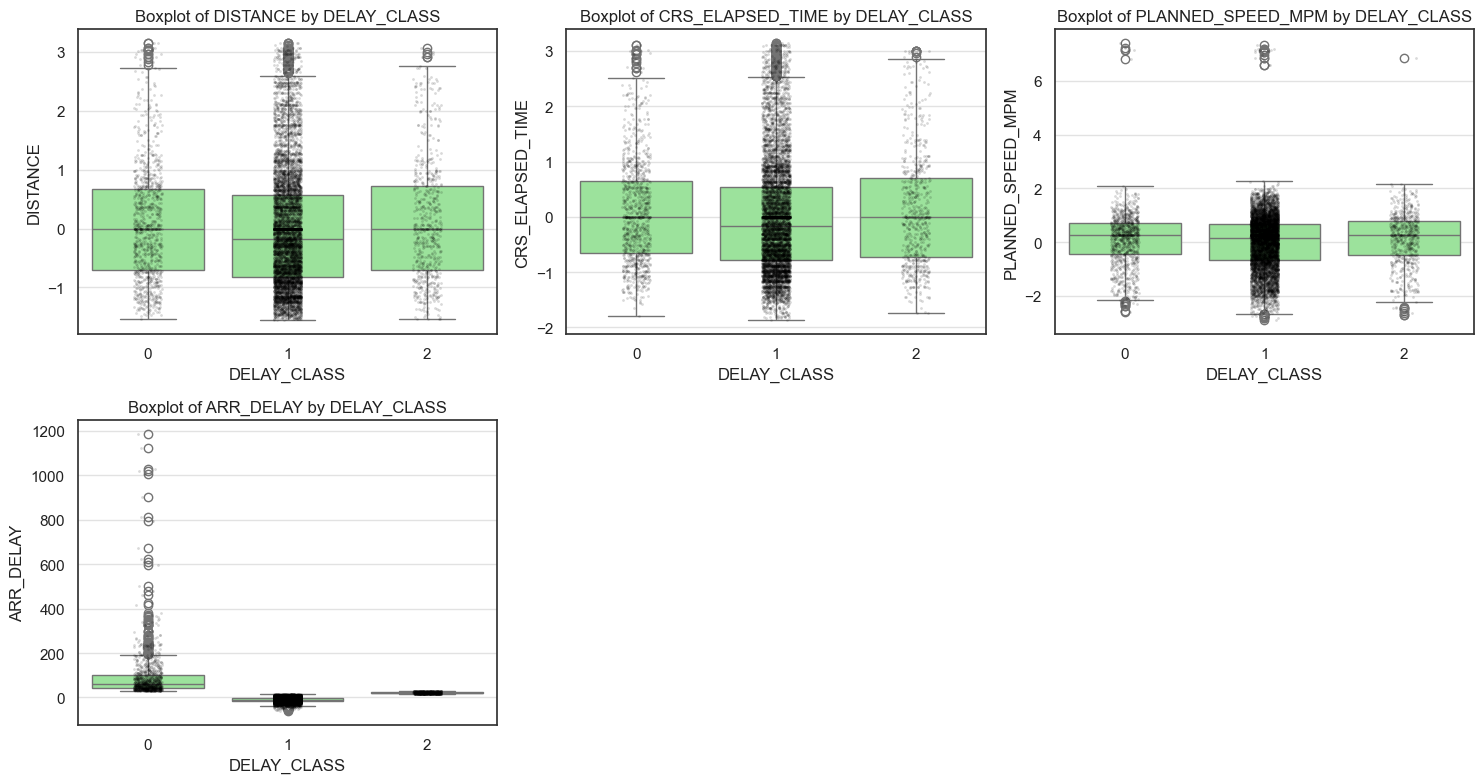

[OK] Grouped boxplots saved: viz_grouped_boxplots_delay_class.png
Generated EDA files:
- eda_boxplots.png
- eda_correlation_matrix.png
- eda_distributions.png
- eda_grouped_boxplots.png
- eda_grouped_distributions.png
- eda_target_distribution.png
- eda_umap_2d.png


In [18]:
# STEP 10: Additional visual diagnostics
logger.info("[STEP 10] Generating additional visual diagnostics...")
viz = DataVisualization(df_features, output_dir=output_dir)
viz.plot_heatmap_top_correlations(top_n=20)

if "DELAY_CLASS" in df_features.columns:
    focus_cols = ["DISTANCE", "CRS_ELAPSED_TIME", "PLANNED_SPEED_MPM", "ARR_DELAY"]
    viz.plot_grouped_feature_distributions(
        columns=focus_cols,
        group_col="DELAY_CLASS",
        filename="viz_grouped_distributions_delay_class.png",
    )
    viz.plot_grouped_boxplots(
        columns=focus_cols,
        group_col="DELAY_CLASS",
        filename="viz_grouped_boxplots_delay_class.png",
    )

generated_eda_files = sorted([p.name for p in output_dir.glob("eda_*.png")])
print("Generated EDA files:")
for name in generated_eda_files:
    print("-", name)


## Phase 5 - Hypothesis Testing and Final Checkpoint

This final phase provides statistical evidence for feature differences across delay classes.

### Statistical output goals

1. Run a full battery of tests per numeric feature.
2. Export each test family as CSV for reporting and traceability.
3. Save the final checkpoint artifact.


In [19]:
logger.info("\n" + "=" * 80)
logger.info("PHASE 5: HYPOTHESIS TESTING AND FINAL CHECKPOINT")
logger.info("=" * 80)

# STEP 11: Hypothesis testing
logger.info("[STEP 11] Running statistical tests...")
hypothesis_tester = HypothesisTester(
    data=df_features,
    labels=df_features["DELAY_CLASS"],
    target_col="DELAY_CLASS",
    verbose=False,
)

summary_report = hypothesis_tester.generate_summary_report()


2026-03-20 17:30:28,488 - INFO - 
2026-03-20 17:30:28,489 - INFO - PHASE 5: HYPOTHESIS TESTING AND FINAL CHECKPOINT
2026-03-20 17:30:28,489 - INFO - ================================================================================
2026-03-20 17:30:28,490 - INFO - [STEP 11] Running statistical tests...


In [20]:
# STEP 12: Export statistical reports
logger.info("[STEP 12] Exporting statistical reports...")
exported_reports = []

for test_name, results_df in summary_report.items():
    if results_df is not None:
        out_csv = output_dir / f"hypothesis_testing_{test_name}.csv"
        results_df.to_csv(out_csv, index=False)
        exported_reports.append(out_csv.name)
        logger.info(f"Report saved: {out_csv.name}")

print("Exported reports:")
for name in exported_reports:
    print("-", name)


2026-03-20 17:30:28,849 - INFO - [STEP 12] Exporting statistical reports...
2026-03-20 17:30:28,854 - INFO - Report saved: hypothesis_testing_normality.csv
2026-03-20 17:30:28,857 - INFO - Report saved: hypothesis_testing_anova.csv
2026-03-20 17:30:28,860 - INFO - Report saved: hypothesis_testing_kruskal_wallis.csv
2026-03-20 17:30:28,863 - INFO - Report saved: hypothesis_testing_levene.csv
2026-03-20 17:30:28,866 - INFO - Report saved: hypothesis_testing_t_tests.csv


Exported reports:
- hypothesis_testing_normality.csv
- hypothesis_testing_anova.csv
- hypothesis_testing_kruskal_wallis.csv
- hypothesis_testing_levene.csv
- hypothesis_testing_t_tests.csv


In [21]:
# STEP 13: Final checkpoint
logger.info("[STEP 13] Saving final checkpoint...")
loader.data = df_features
checkpoint_final_path = dataset_path.parent / "checkpoint_part1_complete.pkl"
loader.save_checkpoint(str(checkpoint_final_path))

logger.info("=" * 80)
logger.info("PIPELINE PART 1 COMPLETED SUCCESSFULLY (NOTEBOOK)")
logger.info("=" * 80)

print("Final checkpoint created:", checkpoint_final_path.exists())
print("Final checkpoint path:", checkpoint_final_path)
print("Artifacts directory:", output_dir)



2026-03-20 17:30:28,924 - INFO - [STEP 13] Saving final checkpoint...
2026-03-20 17:30:28,936 - INFO - ================================================================================
2026-03-20 17:30:28,937 - INFO - PIPELINE PART 1 COMPLETED SUCCESSFULLY (NOTEBOOK)
2026-03-20 17:30:28,938 - INFO - ================================================================================


Checkpoint salvo: C:\Users\angel\Documents\Github\Data Science\DataScience_IA\DataSet\checkpoint_part1_complete.pkl
Final checkpoint created: True
Final checkpoint path: C:\Users\angel\Documents\Github\Data Science\DataScience_IA\DataSet\checkpoint_part1_complete.pkl
Artifacts directory: C:\Users\angel\Documents\Github\Data Science\DataScience_IA\Output_Files
